In [4]:
text_list = []
with open('../data/jokes_merged.txt', 'r') as f:
    for line in f:
        text_list.append(str(line))

In [5]:
len(text_list)

773856

In [6]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

import numpy as np
from tqdm import tqdm

In [7]:
tokenizer = Tokenizer(BPE())
tokenizer.decoder = ByteLevelDecoder()
tokenizer.pre_tokenizer = ByteLevel()

trainer = BpeTrainer(
    vocab_size=5000,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

tokenizer.train_from_iterator(text_list, trainer)

In [8]:
tokenizer.save("bpe_tokenizer.json")

In [9]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

tokenizer.decode(tokenizer.encode("Тестируем токенизатор").ids)

' Тестируем токенизатор'

# Гистограммы по токенам:

In [10]:
import matplotlib.pyplot as plt

In [11]:
tokens_stat = []
batch_size=64
max_ind = 0
max_token_len = 0
drop_counter = 0

# with open('../data/jokes_clean.txt', 'w',  encoding="utf-8") as f:
#     for i in tqdm(range((len(text_list)//batch_size+(len(text_list)%batch_size!=0)))):
#         text_batch = text_list[i*batch_size:(i+1)*batch_size]
#         tokens = tokenizer.encode_batch(text_batch)
#         for j, token in enumerate(tokens):
#             if(len(token.ids)>256):
#                 drop_counter += 1
#                 #print(len(token.ids))
#                 continue
#             if (len(token.ids)>max_token_len):
#                 max_token_len = len(token.ids)
#                 max_ind = i*batch_size+j
#             f.write(text_list[i*batch_size+j].strip().replace('\\r', '')+"\n")
#             tokens_stat.append(len(token.ids))

In [12]:
drop_counter

0

In [59]:
print(text_list[max_ind].replace('\\n', '\n').replace('\\r', ''))

Радио-разговор диспетчера аэропорта Франкфурта и пилота рейса Аэрофлот 4554,
Москва-Франкфурт
Диспетчер:
- Борт 4554. Занять корридор 8 и спуститься на 1000 метров!
Борт 4554:
- Вас понял! Снижаюсь!
Диспетчер:
- Борт 4554! Полоса свободна! Можете садиться!
Борт 4554:
- Понял вас! Сажусь!
....промахивается мимо полосы и снова набирает высоту.
Диспетчер:
- Борт 4554! Вы что, никогда раньше не были во Франкфурте?
Борт 4554:
- Был, б$я! В 1944-ом, но тогда я не садился....!!!!





In [13]:
text_list = []
with open('../data/jokes_clean.txt', 'r') as f:
    for line in f:
        text_list.append(str(line))

In [14]:
for i in tqdm(range((len(text_list)//batch_size+(len(text_list)%batch_size!=0)))):
    text_batch = text_list[i*batch_size:(i+1)*batch_size]
    tokens = tokenizer.encode_batch(text_batch)
    for j, token in enumerate(tokens):
        tokens_stat.append(len(token.ids))

100%|██████████| 11956/11956 [00:25<00:00, 462.99it/s]


In [16]:
np.sum(tokens_stat)

np.int64(32852684)

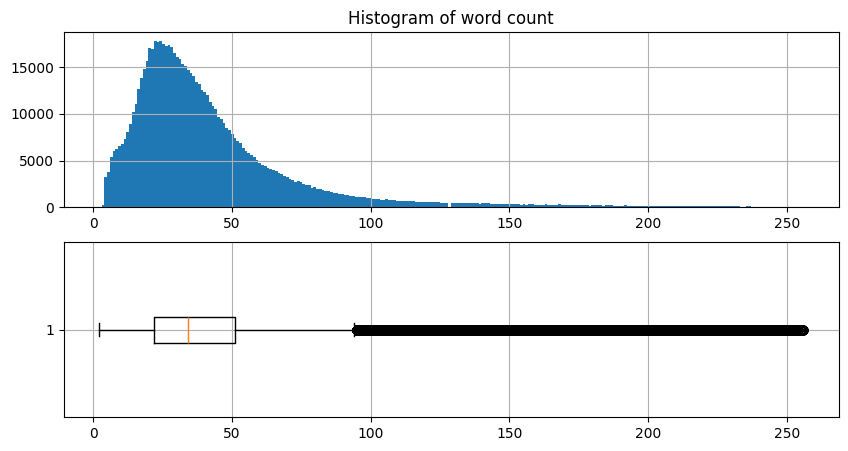

In [15]:
plt.subplots(2,1,figsize=(10,5))

plt.subplot(2,1,1)
plt.title('Histogram of word count')
plt.hist(tokens_stat, 256)
plt.grid(True)

plt.subplot(2,1,2)
plt.boxplot(tokens_stat, vert=False)
plt.grid(True)
plt.show()